In [1]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("/kaggle/input/playground-series-s5e7/train.csv", index_col="id")
test = pd.read_csv("/kaggle/input/playground-series-s5e7/test.csv", index_col="id")

In [4]:
original = pd.read_csv('/kaggle/input/extrovert-vs-introvert-behavior-data/personality_datasert.csv')

In [5]:
train.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
id,,,,,,,,
0,0.0,No,6.0,4.0,No,15.0,5.0,Extrovert
1,1.0,No,7.0,3.0,No,10.0,8.0,Extrovert
2,6.0,Yes,1.0,0.0,NaN,3.0,0.0,Introvert
3,3.0,No,7.0,3.0,No,11.0,5.0,Extrovert
4,1.0,No,4.0,4.0,No,13.0,NaN,Extrovert


In [6]:
train = pd.concat([train, original],ignore_index=True )

In [7]:
train.duplicated().sum()

456

In [9]:
train = train.drop_duplicates()

In [10]:
cat_cols = train.select_dtypes(include=['object']).columns
num_cols = train.select_dtypes(include=['int64', 'float64']).columns

train.replace([np.inf, -np.inf], np.nan, inplace=True)
train[num_cols] = train[num_cols].fillna(train[num_cols].mean())

for col in cat_cols:
    if train[col].isnull().any():
        train[col] = train[col].fillna(train[col].mode()[0])

In [11]:
cat_cols = test.select_dtypes(include=['object']).columns
num_cols = test.select_dtypes(include=['int64', 'float64']).columns

test.replace([np.inf, -np.inf], np.nan, inplace=True)
test[num_cols] = test[num_cols].fillna(test[num_cols].mean())

for col in cat_cols:
    if test[col].isnull().any():
        test[col] = test[col].fillna(test[col].mode()[0])

In [12]:
print(f"The categorical value columns are: {cat_cols.values}")

The categorical value columns are: ['Stage_fear' 'Drained_after_socializing']


In [13]:
le = LabelEncoder()
for col in cat_cols.values:
    train[col] = le.fit_transform(train[col])
    test[col] = le.fit_transform(test[col])

In [14]:
train.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,0.0,0,6.0,4.0,0,15.0,5.000000,Extrovert
1,1.0,0,7.0,3.0,0,10.0,8.000000,Extrovert
2,6.0,1,1.0,0.0,0,3.0,0.000000,Introvert
3,3.0,0,7.0,3.0,0,11.0,5.000000,Extrovert
4,1.0,0,4.0,4.0,0,13.0,4.833566,Extrovert


In [ ]:
train[num_cols] = train[num_cols].astype(int)
test[num_cols] = test[num_cols].astype(int)

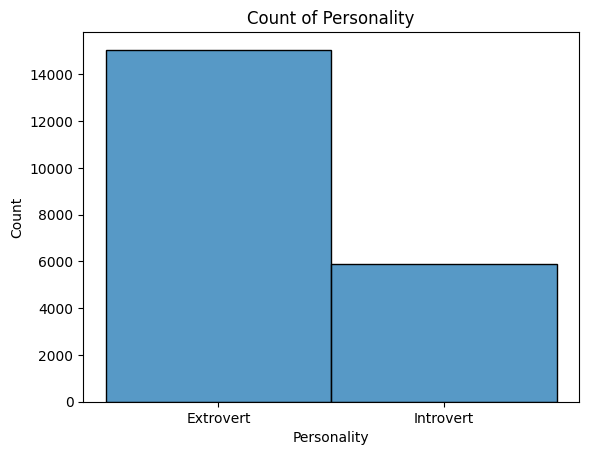

In [15]:
sns.histplot(train['Personality'])
plt.title('Count of Personality')
plt.show()

It is observed from the above plot that there are a lot more of **Extrovert** than **Introvert**.

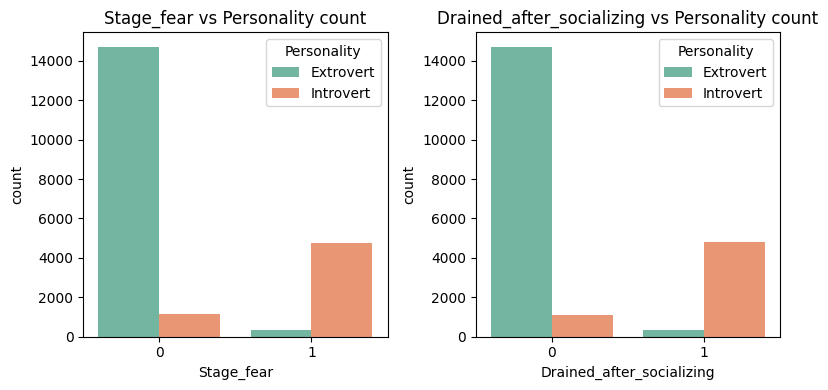

In [16]:
plt.figure(figsize=(8, 2 * len(cat_cols)))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, len(cat_cols), i)  
    sns.countplot(x=train[col], hue=train['Personality'], palette='Set2')
    plt.title(f"{col} vs Personality count") 
    
plt.tight_layout()
plt.show()

From the above plot, it can be said that **Extrovert** has almost no *Stage_fear* and they don't feel *Drained_after_socializing*. **Introverts** are totally opposite.

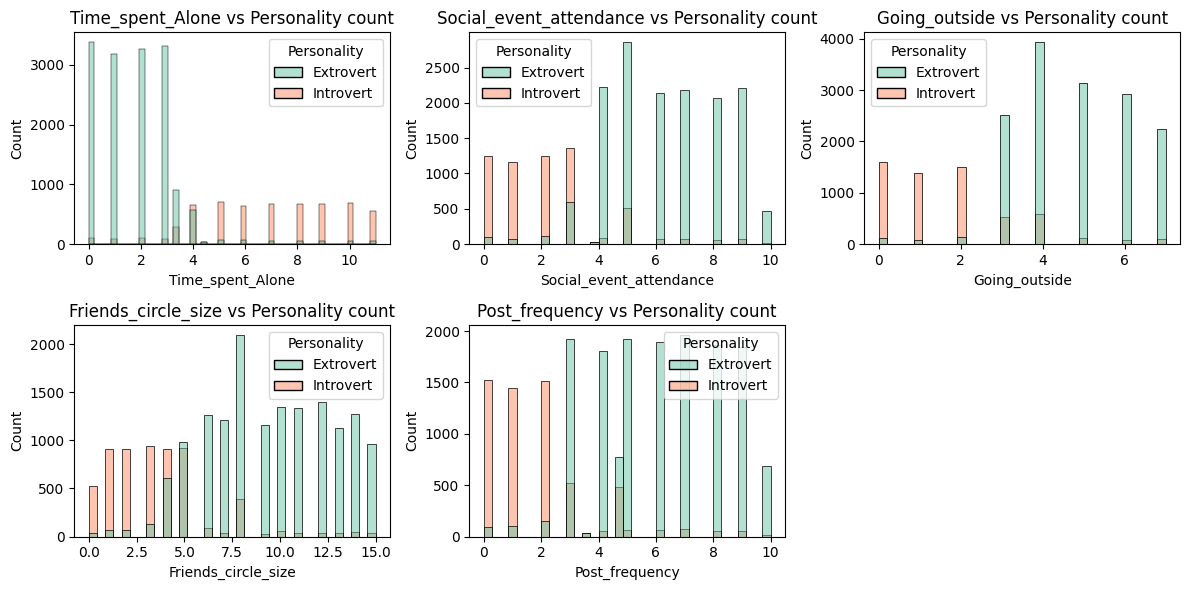

In [17]:
n_plots = len(num_cols)
cols_per_row = math.ceil(n_plots / 2)

plt.figure(figsize=(4 * cols_per_row, 6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, cols_per_row, i)
    sns.histplot(x=col, hue='Personality', data=train, fill=True, palette='Set2')
    plt.title(f"{col} vs Personality count")

plt.tight_layout()
plt.show()


Here it is visible that Introverts has more Time_spent_Alone, less Social_event_attendance, less Going_outside, small friend_circle_size and less Post_frequency.

In [18]:
X = train.drop('Personality', axis=1)
y = train['Personality']
y = le.fit_transform(y)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

For now, all the models are trained with their default hyperparameters.

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=22, stratify=y
)


param_grid_xgb = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
}
param_grid_lgbm = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, -1],
}
param_grid_cat = {
    'iterations': [50, 100],
    'depth': [3, 5],
}
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, None],
}
param_grid_logreg = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear'],
}

# Step 3: Perform Grid Search for each base learner
xgb_base = XGBClassifier(enable_categorical=True, verbosity=0, use_label_encoder=False)
lgbm_base = LGBMClassifier(verbose=-1)
cat_base = CatBoostClassifier(verbose=0, allow_writing_files=False)
rf_base = RandomForestClassifier()
logreg_base = LogisticRegression()

xgb_search = GridSearchCV(xgb_base, param_grid_xgb, cv=3, scoring='accuracy')
lgbm_search = GridSearchCV(lgbm_base, param_grid_lgbm, cv=3, scoring='accuracy')
cat_search = GridSearchCV(cat_base, param_grid_cat, cv=3, scoring='accuracy')
rf_search = GridSearchCV(rf_base, param_grid_rf, cv=3, scoring='accuracy')
logreg_search = GridSearchCV(logreg_base, param_grid_logreg, cv=3, scoring='accuracy')

# Step 4: Fit each grid search
xgb_search.fit(X_train, y_train)
lgbm_search.fit(X_train, y_train)
cat_search.fit(X_train, y_train)
rf_search.fit(X_train, y_train)
logreg_search.fit(X_train, y_train)

# Step 5: Voting Classifier with best-found estimators
model = VotingClassifier(estimators=[
    ('xgb', xgb_search.best_estimator_),
    ('lgbm', lgbm_search.best_estimator_),
    ('cat', cat_search.best_estimator_),
    ('rf', rf_search.best_estimator_),
    ('logreg', logreg_search.best_estimator_),
], voting='soft')

model.fit(X_train, y_train)


VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=True,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rat...
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=50, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('lgbm', LGBMClassifier(max_depth=3, verbose=-1)),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x7af38356bcd0>),
                             ('rf', RandomForestClassifier(max_depth=5)),
                             ('logreg',
                              LogisticRegression(C=0.1, solver='liblinear'))],
                 voting='soft')

In [23]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# -------------- XGBoost --------------
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'enable_categorical': True,
        'verbosity': 0,
    }
    model = XGBClassifier(**params, use_label_encoder=False)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20)
best_xgb = XGBClassifier(**study_xgb.best_params, use_label_encoder=False)

# -------------- LightGBM --------------
def objective_lgbm(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'verbose': -1,
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

study_lgbm = optuna.create_study(direction="maximize")
study_lgbm.optimize(objective_lgbm, n_trials=20)
best_lgbm = LGBMClassifier(**study_lgbm.best_params)

# -------------- CatBoost --------------
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 50, 200),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'verbose': 0,
        'allow_writing_files': False,
    }
    model = CatBoostClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=20)
best_cat = CatBoostClassifier(**study_cat.best_params)

# -------------- RandomForest --------------
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=20)
best_rf = RandomForestClassifier(**study_rf.best_params)

# -------------- Logistic Regression --------------
def objective_logreg(trial):
    params = {
        'C': trial.suggest_float('C', 1e-2, 10.0, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        'max_iter': 200,
    }
    model = LogisticRegression(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

study_logreg = optuna.create_study(direction="maximize")
study_logreg.optimize(objective_logreg, n_trials=20)
best_logreg = LogisticRegression(**study_logreg.best_params)

# -------------- Voting Ensemble --------------

model = VotingClassifier(estimators=[
    ('xgb', best_xgb),
    ('lgbm', best_lgbm),
    ('cat', best_cat),
    ('rf', best_rf),
    ('logreg', best_logreg)
], voting='soft')

model.fit(X_train, y_train)

[I 2025-07-20 04:02:40,910] A new study created in memory with name: no-name-780bfcd7-0851-4b75-aed5-01c42103d23f
[I 2025-07-20 04:02:41,414] Trial 0 finished with value: 0.9627995278534964 and parameters: {'n_estimators': 98, 'max_depth': 6, 'learning_rate': 0.08497588771053172}. Best is trial 0 with value: 0.9627995278534964.
[I 2025-07-20 04:02:41,801] Trial 1 finished with value: 0.7180755982838076 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.001209063226488753}. Best is trial 0 with value: 0.9627995278534964.
[I 2025-07-20 04:02:42,582] Trial 2 finished with value: 0.9628591794650557 and parameters: {'n_estimators': 158, 'max_depth': 7, 'learning_rate': 0.025649761329756635}. Best is trial 2 with value: 0.9628591794650557.
[I 2025-07-20 04:02:43,024] Trial 3 finished with value: 0.7180755982838076 and parameters: {'n_estimators': 136, 'max_depth': 5, 'learning_rate': 0.0021184571800139606}. Best is trial 2 with value: 0.9628591794650557.
[I 2025-07-20 0

0:	learn: 0.4790587	total: 2.2ms	remaining: 215ms
1:	learn: 0.3602559	total: 4.38ms	remaining: 212ms
2:	learn: 0.2863625	total: 6.13ms	remaining: 196ms
3:	learn: 0.2389425	total: 7.79ms	remaining: 185ms
4:	learn: 0.2079845	total: 9.7ms	remaining: 182ms
5:	learn: 0.1874768	total: 11.3ms	remaining: 175ms
6:	learn: 0.1736765	total: 12.9ms	remaining: 170ms
7:	learn: 0.1656839	total: 14.6ms	remaining: 166ms
8:	learn: 0.1597068	total: 16.2ms	remaining: 162ms
9:	learn: 0.1557138	total: 18ms	remaining: 160ms
10:	learn: 0.1534353	total: 19.7ms	remaining: 158ms
11:	learn: 0.1516659	total: 21.4ms	remaining: 155ms
12:	learn: 0.1505532	total: 23.1ms	remaining: 153ms
13:	learn: 0.1497512	total: 25.3ms	remaining: 154ms
14:	learn: 0.1492860	total: 27ms	remaining: 151ms
15:	learn: 0.1487989	total: 28.9ms	remaining: 150ms
16:	learn: 0.1483805	total: 30.6ms	remaining: 148ms
17:	learn: 0.1480871	total: 32.2ms	remaining: 145ms
18:	learn: 0.1474688	total: 33.9ms	remaining: 143ms
19:	learn: 0.1473401	total: 

VotingClassifier(estimators=[('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_ra...
                                            n_estimators=157, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=None, ...)),
                             ('lgbm',
                              LGBMClassifier(learning_rate=0.05951209248500042,
                                             max_depth=10, n_estimators=160)),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x7af3825da350>),
                             ('rf',
                              RandomForestClassifier(max_depth=4,
                                                     n_estimators=180)),
                             ('logreg',
                              LogisticRegression(C=0.10594415145406866,
                                                 solver='liblinear'))],
                 voting='soft')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22, stratify=y)

xgb = XGBClassifier(enable_categorical=True, verbosity=0)
lgbm = LGBMClassifier(verbose=-1)
cat = CatBoostClassifier(verbose=0, allow_writing_files=False)
rf = RandomForestClassifier()
logreg = LogisticRegression()

model = VotingClassifier(estimators=[
    ('xgb', xgb),
    ('lgbm', lgbm),
    ('cat', cat),
    ('rf', rf),
    ('logreg', logreg)
], voting='soft') 

model.fit(X_train, y_train)

In [24]:
y_pred = model.predict(X_test)
print(f"VotingClassifier Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Classification Report: {classification_report(y_test, y_pred)}")

VotingClassifier Accuracy: 0.9649
Classification Report:               precision    recall  f1-score   support

           0       0.98      0.98      0.98      3012
           1       0.94      0.94      0.94      1182

    accuracy                           0.96      4194
   macro avg       0.96      0.96      0.96      4194
weighted avg       0.96      0.96      0.96      4194



# <div style="text-align:center; border-radius:15px 100px; padding:7px; color:white; margin:0; font-size:110%; font-family:Consolas; background-color:#de7710; overflow:hidden">Submission</div>

This is the final submission file, where `le.inverse_transform()` is used to convert back to categorical labels: *Introvert* & *Extrovert*. The `id` values are obtained from the *sample_submission.csv* file.

In [22]:
test_pred = model.predict(test)
test_pred_labels = le.inverse_transform(test_pred)

sub = pd.read_csv('/kaggle/input/playground-series-s5e7/sample_submission.csv')
submission = pd.DataFrame({
    'id': sub['id'],
    'Personality': test_pred_labels
})

submission.to_csv('submission.csv', index=False)